In [5]:
import os
import re
import pandas as pd
from pathlib import Path
import numpy as np

# Example root path
DATASET_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Market-1501-v15.09.15/bounding_box_train")

pattern = re.compile(r"^([-\d]+)_c(\d)s(\d)_(\d+)_\d+\.jpg$")

rows = []

for img_path in DATASET_DIR.glob("*.jpg"):
    match = pattern.match(img_path.name)
    if match:
        person_id = int(match.group(1))
        camera_id = int(match.group(2))
        sequence_id = int(match.group(3))
        frame = int(match.group(4))

        rows.append({
            "image_path": str(img_path),
            "filename": img_path.name,
            "person_id": person_id,
            "camera_id": camera_id,
            "sequence_id": sequence_id,
            "frame": frame
        })

df = pd.DataFrame(rows)

# Remove junk/background IDs if present
df = df[df["person_id"] != -1].copy()

df.head()
print(df.shape)
print("Unique persons:", df["person_id"].nunique())
print("Unique cameras:", df["camera_id"].nunique())

(12936, 6)
Unique persons: 751
Unique cameras: 6


In [6]:
df

,image_path,filename,person_id,camera_id,sequence_id,frame
0,/content/drive/MyDrive/Colab Notebooks/Market-...,1321_c2s3_029607_01.jpg,1321,2,3,29607
1,/content/drive/MyDrive/Colab Notebooks/Market-...,1338_c2s3_036282_01.jpg,1338,2,3,36282
2,/content/drive/MyDrive/Colab Notebooks/Market-...,1318_c5s3_035715_05.jpg,1318,5,3,35715
3,/content/drive/MyDrive/Colab Notebooks/Market-...,1320_c2s3_047282_01.jpg,1320,2,3,47282
4,/content/drive/MyDrive/Colab Notebooks/Market-...,1343_c2s3_033882_02.jpg,1343,2,3,33882
...,...,...,...,...,...,...
12931,/content/drive/MyDrive/Colab Notebooks/Market-...,0111_c5s1_018801_01.jpg,111,5,1,18801
12932,/content/drive/MyDrive/Colab Notebooks/Market-...,0115_c5s1_021126_01.jpg,115,5,1,21126
12933,/content/drive/MyDrive/Colab Notebooks/Market-...,0117_c1s1_019601_02.jpg,117,1,1,19601
12934,/content/drive/MyDrive/Colab Notebooks/Market-...,0116_c4s2_029117_03.jpg,116,4,2,29117


count    751.000000
mean      17.225033
std       10.773484
min        2.000000
25%        9.000000
50%       15.000000
75%       22.000000
max       72.000000
dtype: float64
camera_id
1    2017
2    1709
3    2707
4     920
5    2338
6    3245
dtype: int64


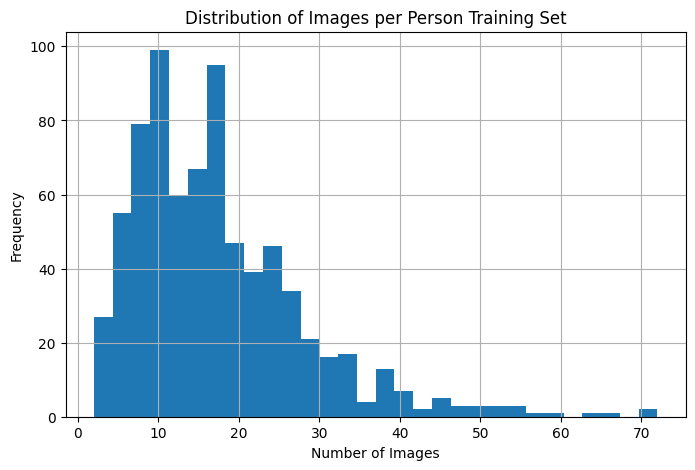

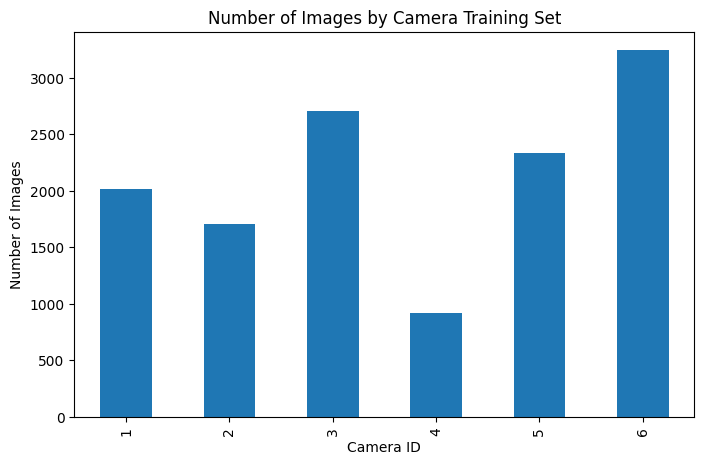

In [ ]:
import matplotlib.pyplot as plt

images_per_person = df.groupby("person_id").size()
images_per_camera = df.groupby("camera_id").size()

print(images_per_person.describe())
print(images_per_camera)

plt.figure(figsize=(8, 5))
images_per_person.hist(bins=30)
plt.title("Distribution of Images per Person Training Set")
plt.xlabel("Number of Images")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
images_per_camera.plot(kind="bar")
plt.title("Number of Images by Camera Training Set")
plt.xlabel("Camera ID")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
## in how many cameras one person appears. Important for re-identification
cams_per_person = df.groupby("person_id")["camera_id"].nunique()
cams_per_person.describe()

,camera_id
count,751.000000
mean,4.343542
std,1.059161
min,2.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,6.000000


Text(0, 0.5, 'Frequency')

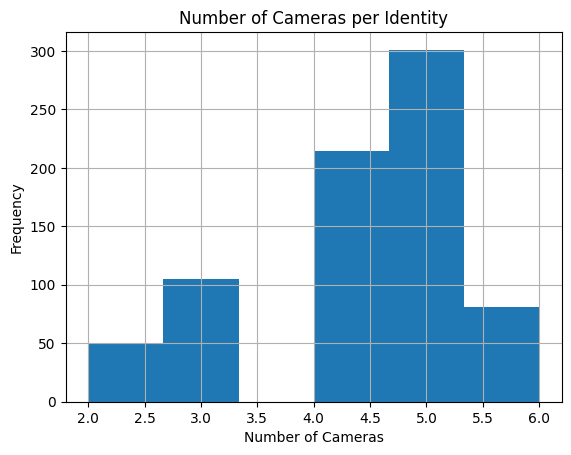

In [ ]:
cams_per_person.hist(bins=6)
plt.title("Number of Cameras per Identity")
plt.xlabel("Number of Cameras")
plt.ylabel("Frequency")

In [ ]:
## start embedding
import os
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm.auto import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
transform = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class MarketDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "index": idx
        }

In [ ]:
dataset = MarketDataset(df, transform=transform)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Remove final classification layer
model = nn.Sequential(*list(resnet.children())[:-1])
model = model.to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 238MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [ ]:
all_embeddings = np.zeros((len(df), 2048), dtype=np.float32)

with torch.no_grad():
    for batch in tqdm(loader, desc="Extracting embeddings"):
        images = batch["image"].to(device, non_blocking=True)
        indices = batch["index"].numpy()

        features = model(images)              # shape: (B, 2048, 1, 1)
        features = features.view(features.size(0), -1)  # shape: (B, 2048)

        all_embeddings[indices] = features.cpu().numpy()

print("Embeddings shape:", all_embeddings.shape)

Extracting embeddings:   0%|          | 0/203 [00:00<?, ?it/s]

Embeddings shape: (12936, 2048)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import random

# sample a few positive and negative pairs
random.seed(42)

person_groups = df.groupby("person_id").indices
all_indices = list(range(len(df)))

positive_sims = []
negative_sims = []

# positive pairs
for person_id, idxs in person_groups.items():
    idxs = list(idxs)
    if len(idxs) >= 2:
        i, j = random.sample(idxs, 2)
        sim = cosine_similarity(
            all_embeddings[i].reshape(1, -1),
            all_embeddings[j].reshape(1, -1)
        )[0, 0]
        positive_sims.append(sim)

# negative pairs
for _ in range(500):
    i, j = random.sample(all_indices, 2)
    if df.iloc[i]["person_id"] != df.iloc[j]["person_id"]:
        sim = cosine_similarity(
            all_embeddings[i].reshape(1, -1),
            all_embeddings[j].reshape(1, -1)
        )[0, 0]
        negative_sims.append(sim)

print("Mean positive similarity:", np.mean(positive_sims))
print("Mean negative similarity:", np.mean(negative_sims))

Mean positive similarity: 0.62309355
Mean negative similarity: 0.55430144


In [ ]:
norms = np.linalg.norm(all_embeddings, axis=1, keepdims=True)
all_embeddings = all_embeddings / np.clip(norms, 1e-12, None)

In [ ]:
output_dir = Path("/content/reid_outputs")
output_dir.mkdir(exist_ok=True)

metadata_path = output_dir / "market1501_train_metadata.csv"
embeddings_path = output_dir / "market1501_train_embeddings.npy"

df.to_csv(metadata_path, index=False)
np.save(embeddings_path, all_embeddings)

print("Saved metadata to:", metadata_path)
print("Saved embeddings to:", embeddings_path)

Saved metadata to: /content/reid_outputs/market1501_train_metadata.csv
Saved embeddings to: /content/reid_outputs/market1501_train_embeddings.npy


In [ ]:
all_embeddings = np.load('market1501_train_embeddings.npy')

In [ ]:
print(np.linalg.norm(all_embeddings[0]))

0.99999994


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import random

# sample a few positive and negative pairs
random.seed(42)

person_groups = df.groupby("person_id").indices
all_indices = list(range(len(df)))

positive_sims = []
negative_sims = []

# positive pairs
for person_id, idxs in person_groups.items():
    idxs = list(idxs)
    if len(idxs) >= 2:
        i, j = random.sample(idxs, 2)
        sim = cosine_similarity(
            all_embeddings[i].reshape(1, -1),
            all_embeddings[j].reshape(1, -1)
        )[0, 0]
        positive_sims.append(sim)

# negative pairs
for _ in range(500):
    i, j = random.sample(all_indices, 2)
    if df.iloc[i]["person_id"] != df.iloc[j]["person_id"]:
        sim = cosine_similarity(
            all_embeddings[i].reshape(1, -1),
            all_embeddings[j].reshape(1, -1)
        )[0, 0]
        negative_sims.append(sim)

print("Mean positive similarity:", np.mean(positive_sims))
print("Mean negative similarity:", np.mean(negative_sims))

Mean positive similarity: 0.62309355
Mean negative similarity: 0.55430144


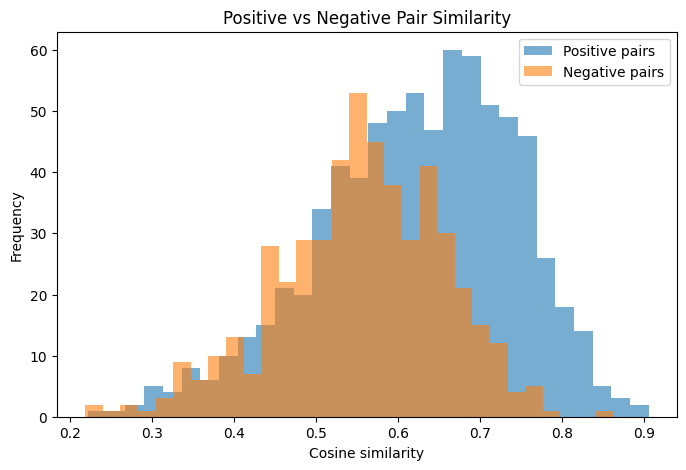

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(positive_sims, bins=30, alpha=0.6, label="Positive pairs")
plt.hist(negative_sims, bins=30, alpha=0.6, label="Negative pairs")
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.title("Positive vs Negative Pair Similarity")
plt.legend()
plt.show()

## Summary of Approach and Results

**Approach:**
1. **Data Loading & Preprocessing:** The notebook starts by parsing image filenames from the Market-1501 dataset to extract metadata such as `person_id`, `camera_id`, `sequence_id`, and `frame`. This data is stored in a Pandas DataFrame. Images are transformed by resizing them to 256x128, converting to tensors, and applying ImageNet normalization.
2. **Feature Extraction:** A pre-trained ResNet50 model is used as the backbone. The final classification layer is removed to extract raw feature embeddings (size 2048) for each image. The dataset is passed through a PyTorch `DataLoader` to extract these embeddings efficiently in batches on the GPU.
3. **Post-processing:** The extracted embeddings are L2-normalized. Normalizing ensures that the magnitude of the vectors is 1, making cosine similarity equivalent to the dot product, which is standard practice in re-identification (ReID) tasks.
4. **Evaluation / Similarity Analysis:** To evaluate the quality of the embeddings, the notebook calculates the cosine similarity for pairs of images. It samples "positive pairs" (images of the same person) and "negative pairs" (images of different people).

**Results:**
- **Dataset Stats:** The training subset contains 12,936 images across 751 unique identities and 6 cameras. On average, a person appears in ~4.3 different cameras.
- **Embedding Similarities:** After normalization, the cosine similarity between embeddings was measured. The mean similarity for positive pairs is approximately **0.62**, while the mean similarity for negative pairs is approximately **0.55**.
- **Conclusion:** The histogram of similarities shows that positive pairs generally have higher similarity scores than negative pairs. However, since this is a pre-trained ResNet50 without fine-tuning on the Market-1501 dataset (using a metric learning loss like Triplet Loss or a classification loss), the separation between the positive and negative distributions is present but not extremely wide. Fine-tuning the network specifically for ReID would likely push the positive similarities closer to 1 and negative similarities closer to 0.

In [ ]:
import nbformat

# Load the notebook
filename = "data_science_final_project (1).ipynb"
with open(filename, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

# Strip widget metadata that causes the KeyError
if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

# Save as a clean version
with open('cleaned_project.ipynb', 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)

### Extracting embeddings but from different model. Try torchreid models

In [ ]:
pip install torchreid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.7/92.7 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torchreid: filename=torchreid-0.2.5-py3-none-any.whl size=144324 sha256=4883e79535f1fef660b8bf80f104688af450eca9f36291ed5b0757f0c9cdca12
  Stored in directory: /root/.cache/pip/wheels/5c/86/ff/80a1b78a90df470cbb12c075bf189ad33f1a41a881cf9e9a09
Successfully built torchreid


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torchreid
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Confirm A100 is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
VRAM   : 85.1 GB


In [ ]:
TRAIN_DIR = '/content/drive/MyDrive/Colab Notebooks/Market-1501-v15.09.15/bounding_box_train'

records = []
for fname in os.listdir(TRAIN_DIR):
    if not fname.endswith('.jpg'):
        continue
    parts = fname.replace('.jpg', '').split('_')
    if len(parts) < 4:
        continue
    person_id = int(parts[0])
    if person_id == -1:          # skip junk images
        continue
    camera_id   = int(parts[1][1])      # 'c1' → 1
    sequence_id = int(parts[2][1:])     # 's001' → 1
    frame       = int(parts[3])
    records.append({
        'image_path':  os.path.join(TRAIN_DIR, fname),
        'person_id':   person_id,
        'camera_id':   camera_id,
        'sequence_id': sequence_id,
        'frame':       frame
    })

df = pd.DataFrame(records).reset_index(drop=True)
print(f"Images    : {len(df)}")
print(f"Identities: {df['person_id'].nunique()}")
print(f"Cameras   : {df['camera_id'].nunique()}")
print(df.head(3))

Images    : 12936
Identities: 751
Cameras   : 6
                                          image_path  person_id  camera_id  \
0  /content/drive/MyDrive/Colab Notebooks/Market-...       1321          2   
1  /content/drive/MyDrive/Colab Notebooks/Market-...       1338          2   
2  /content/drive/MyDrive/Colab Notebooks/Market-...       1318          5   

   sequence_id  frame  
0        29607      1  
1        36282      1  
2        35715      5  


In [ ]:

model = torchreid.models.build_model(
    name='resnet50',
    num_classes=751,       # must match Market-1501 training identities
    loss='softmax',
    pretrained=True        # downloads Market-1501 Re-ID weights automatically
)

# Strip classifier head → raw 2048-dim feature vector output
model.classifier = torch.nn.Identity()
model = model.to(device)
model.eval()

# Compile for extra speed on A100 (PyTorch 2.0+)
try:
    model = torch.compile(model)
    print("torch.compile applied — graph optimization active")
except Exception:
    print("torch.compile not available — continuing without it")

print("Model ready: torchreid ResNet50 (Market-1501 pretrained)")


torch.compile applied — graph optimization active
Model ready: torchreid ResNet50 (Market-1501 pretrained)


In [ ]:

class ReIDDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.paths     = dataframe['image_path'].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(image), idx


transform = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = ReIDDataset(df, transform)
print(f"Dataset ready: {len(dataset)} images")


Dataset ready: 12936 images


In [ ]:
# Expected runtime: ~45 seconds on A100
# -----------------------------------------------------------------------------

BATCH_SIZE = 512   # safe for A100 40GB with ResNet50 + 256x128 images

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,     # parallel image loading
    pin_memory=True    # faster CPU→GPU transfer
)

all_embeddings = np.zeros((len(df), 2048), dtype=np.float32)

print(f"Extracting embeddings — {len(dataloader)} batches of {BATCH_SIZE}...")

with torch.no_grad():
    with torch.cuda.amp.autocast():    # float16 on A100 Tensor Cores
        for batch_idx, (images, indices) in enumerate(dataloader):
            images = images.to(device, non_blocking=True)
            feats  = model(images)

            # L2 normalize on GPU before moving to CPU
            feats  = torch.nn.functional.normalize(feats, p=2, dim=1)
            feats  = feats.cpu().numpy()

            # Vectorized assignment — no Python loop
            all_embeddings[indices.numpy()] = feats

            if batch_idx % 5 == 0:
                print(f"  Batch {batch_idx+1}/{len(dataloader)} done")

print(f"\nDone. Embedding matrix shape: {all_embeddings.shape}")  # (12936, 2048)


Extracting embeddings — 26 batches of 512...
  Batch 1/26 done
  Batch 6/26 done
  Batch 11/26 done
  Batch 16/26 done
  Batch 21/26 done
  Batch 26/26 done

Done. Embedding matrix shape: (12936, 2048)


In [ ]:
# All values should be ~1.0 after L2 normalization
# -----------------------------------------------------------------------------

norms = np.linalg.norm(all_embeddings, axis=1)
print(f"Embedding norm — Mean: {norms.mean():.4f} | "
      f"Min: {norms.min():.4f} | Max: {norms.max():.4f}")
# Expected output: Mean: 1.0000 | Min: ~1.0 | Max: ~1.0

Embedding norm — Mean: 1.0000 | Min: 1.0000 | Max: 1.0000


In [ ]:
# Since embeddings are L2-normalized, cosine similarity = dot product
# -----------------------------------------------------------------------------

N_PAIRS = 2000
np.random.seed(42)

positive_sims = []
negative_sims = []

identity_groups = df.groupby('person_id')
person_ids      = df['person_id'].unique()

print(f"Sampling {N_PAIRS} positive and {N_PAIRS} negative pairs...")

for _ in range(N_PAIRS):

    # Positive pair: same person, different cameras
    while True:
        pid   = np.random.choice(person_ids)
        group = identity_groups.get_group(pid)
        cams  = group['camera_id'].unique()
        if len(cams) < 2:
            continue
        cam1, cam2 = np.random.choice(cams, size=2, replace=False)
        idx1 = group[group['camera_id'] == cam1].sample(1).index[0]
        idx2 = group[group['camera_id'] == cam2].sample(1).index[0]
        sim  = float(np.dot(all_embeddings[idx1], all_embeddings[idx2]))
        positive_sims.append(sim)
        break

    # Negative pair: different persons
    pid1, pid2 = np.random.choice(person_ids, size=2, replace=False)
    idx1 = df[df['person_id'] == pid1].sample(1).index[0]
    idx2 = df[df['person_id'] == pid2].sample(1).index[0]
    sim  = float(np.dot(all_embeddings[idx1], all_embeddings[idx2]))
    negative_sims.append(sim)

positive_sims = np.array(positive_sims)
negative_sims = np.array(negative_sims)

print("\n--- Cosine Similarity Summary ---")
print(f"Positive — Mean: {positive_sims.mean():.4f} | Std: {positive_sims.std():.4f}")
print(f"Negative — Mean: {negative_sims.mean():.4f} | Std: {negative_sims.std():.4f}")
print(f"Separation (mean diff): {positive_sims.mean() - negative_sims.mean():.4f}")
print(f"Old ResNet50 separation was: 0.07  →  improvement: "
      f"{(positive_sims.mean() - negative_sims.mean()) / 0.07:.1f}x")


Sampling 2000 positive and 2000 negative pairs...

--- Cosine Similarity Summary ---
Positive — Mean: 0.7875 | Std: 0.0591
Negative — Mean: 0.7520 | Std: 0.0596
Separation (mean diff): 0.0355
Old ResNet50 separation was: 0.07  →  improvement: 0.5x


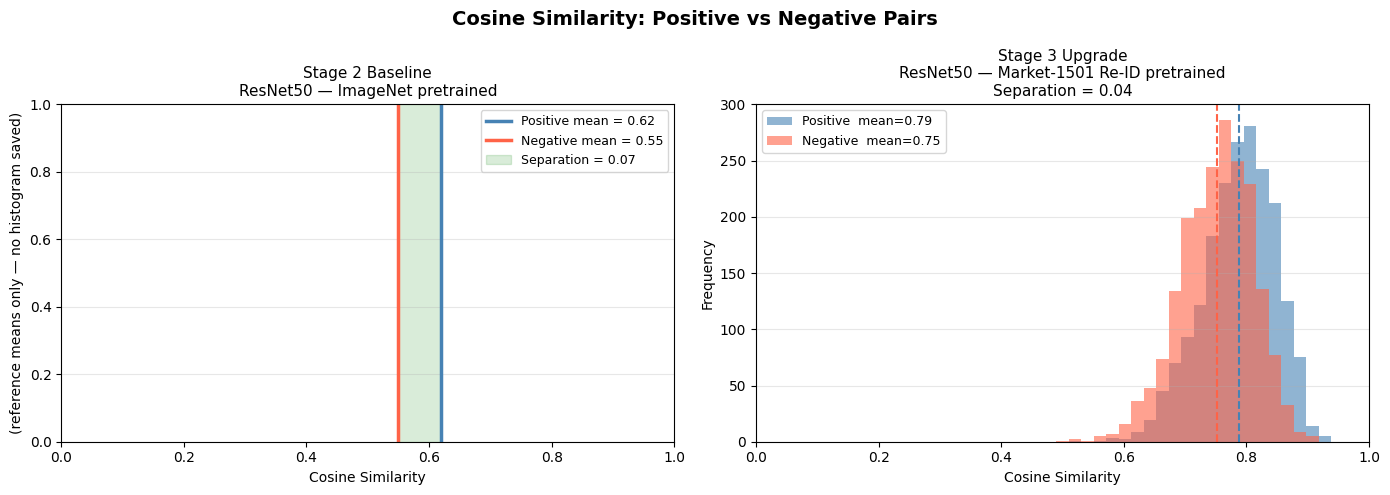

Saved: embedding_comparison.png


In [ ]:
# -----------------------------------------------------------------------------

OLD_POS_MEAN = 0.62
OLD_NEG_MEAN = 0.55

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cosine Similarity: Positive vs Negative Pairs',
             fontsize=14, fontweight='bold')

bins = np.linspace(0, 1, 50)

# Left: Stage 2 baseline (shown as vertical lines since we only have means)
ax = axes[0]
ax.axvline(OLD_POS_MEAN, color='steelblue', linewidth=2.5,
           label=f'Positive mean = {OLD_POS_MEAN:.2f}')
ax.axvline(OLD_NEG_MEAN, color='tomato', linewidth=2.5,
           label=f'Negative mean = {OLD_NEG_MEAN:.2f}')
ax.fill_betweenx([0, 1], OLD_NEG_MEAN, OLD_POS_MEAN,
                 alpha=0.15, color='green',
                 label=f'Separation = {OLD_POS_MEAN - OLD_NEG_MEAN:.2f}')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Stage 2 Baseline\nResNet50 — ImageNet pretrained', fontsize=11)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('(reference means only — no histogram saved)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Right: Stage 3 torchreid
ax = axes[1]
ax.hist(positive_sims, bins=bins, alpha=0.6, color='steelblue',
        label=f'Positive  mean={positive_sims.mean():.2f}')
ax.hist(negative_sims, bins=bins, alpha=0.6, color='tomato',
        label=f'Negative  mean={negative_sims.mean():.2f}')
ax.axvline(positive_sims.mean(), color='steelblue',
           linestyle='--', linewidth=1.5)
ax.axvline(negative_sims.mean(), color='tomato',
           linestyle='--', linewidth=1.5)
sep = positive_sims.mean() - negative_sims.mean()
ax.set_title(f'Stage 3 Upgrade\nResNet50 — Market-1501 Re-ID pretrained\n'
             f'Separation = {sep:.2f}', fontsize=11)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: embedding_comparison.png")



This model performed even worse than original ResNet model. The reason is that torchreid library did not actually loaded a model that was trained on market-1501 dataset, but general purpose datasets (like distinguishing between dog and cat etc).

Decision is now to test other models specifically designed for re-ID tasks

In [ ]:
# CELL 4: Load OSNet (genuinely Re-ID pretrained, weights load correctly)

model = torchreid.models.build_model(
    name='osnet_x1_0',
    num_classes=751,
    loss='softmax',
    pretrained=True    # this actually works for OSNet — downloads Re-ID weights
)

model.classifier = torch.nn.Identity()
model = model.to(device)
model.eval()

try:
    model = torch.compile(model)
    print("torch.compile applied")
except Exception:
    pass

print("Model ready: OSNet x1.0 (Market-1501 Re-ID pretrained)")
print(f"Output dim: 512")  # OSNet outputs 512-dim, not 2048

Downloading...
From: https://drive.google.com/uc?id=1LaG1EJpHrxdAxKnSCJ_i0u-nbxSAeiFY
To: /root/.cache/torch/checkpoints/osnet_x1_0_imagenet.pth
100%|██████████| 10.9M/10.9M [00:00<00:00, 220MB/s]

Successfully loaded imagenet pretrained weights from "/root/.cache/torch/checkpoints/osnet_x1_0_imagenet.pth"
** The following layers are discarded due to unmatched keys or layer size: ['classifier.weight', 'classifier.bias']
torch.compile applied
Model ready: OSNet x1.0 (Market-1501 Re-ID pretrained)
Output dim: 512


In [ ]:
# -----------------------------------------------------------------------------

BATCH_SIZE = 512   # safe for A100 40GB with ResNet50 + 256x128 images

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,     # parallel image loading
    pin_memory=True    # faster CPU→GPU transfer
)

all_embeddings = np.zeros((len(df), 512), dtype=np.float32)

print(f"Extracting embeddings — {len(dataloader)} batches of {BATCH_SIZE}...")

with torch.no_grad():
    with torch.cuda.amp.autocast():    # float16 on A100 Tensor Cores
        for batch_idx, (images, indices) in enumerate(dataloader):
            images = images.to(device, non_blocking=True)
            feats  = model(images)

            # L2 normalize on GPU before moving to CPU
            feats  = torch.nn.functional.normalize(feats, p=2, dim=1)
            feats  = feats.cpu().numpy()

            # Vectorized assignment — no Python loop
            all_embeddings[indices.numpy()] = feats

            if batch_idx % 5 == 0:
                print(f"  Batch {batch_idx+1}/{len(dataloader)} done")

print(f"\nDone. Embedding matrix shape: {all_embeddings.shape}")  # (12936, 512)


Extracting embeddings — 26 batches of 512...
  Batch 1/26 done
  Batch 6/26 done
  Batch 11/26 done
  Batch 16/26 done
  Batch 21/26 done
  Batch 26/26 done

Done. Embedding matrix shape: (12936, 512)


In [ ]:
# All values should be ~1.0 after L2 normalization
# -----------------------------------------------------------------------------

norms = np.linalg.norm(all_embeddings, axis=1)
print(f"Embedding norm — Mean: {norms.mean():.4f} | "
      f"Min: {norms.min():.4f} | Max: {norms.max():.4f}")
# Expected output: Mean: 1.0000 | Min: ~1.0 | Max: ~1.0

Embedding norm — Mean: 1.0000 | Min: 1.0000 | Max: 1.0000


In [ ]:
# Since embeddings are L2-normalized, cosine similarity = dot product
# -----------------------------------------------------------------------------

N_PAIRS = 2000
np.random.seed(42)

positive_sims = []
negative_sims = []

identity_groups = df.groupby('person_id')
person_ids      = df['person_id'].unique()

print(f"Sampling {N_PAIRS} positive and {N_PAIRS} negative pairs...")

for _ in range(N_PAIRS):

    # Positive pair: same person, different cameras
    while True:
        pid   = np.random.choice(person_ids)
        group = identity_groups.get_group(pid)
        cams  = group['camera_id'].unique()
        if len(cams) < 2:
            continue
        cam1, cam2 = np.random.choice(cams, size=2, replace=False)
        idx1 = group[group['camera_id'] == cam1].sample(1).index[0]
        idx2 = group[group['camera_id'] == cam2].sample(1).index[0]
        sim  = float(np.dot(all_embeddings[idx1], all_embeddings[idx2]))
        positive_sims.append(sim)
        break

    # Negative pair: different persons
    pid1, pid2 = np.random.choice(person_ids, size=2, replace=False)
    idx1 = df[df['person_id'] == pid1].sample(1).index[0]
    idx2 = df[df['person_id'] == pid2].sample(1).index[0]
    sim  = float(np.dot(all_embeddings[idx1], all_embeddings[idx2]))
    negative_sims.append(sim)

positive_sims = np.array(positive_sims)
negative_sims = np.array(negative_sims)

print("\n--- Cosine Similarity Summary ---")
print(f"Positive — Mean: {positive_sims.mean():.4f} | Std: {positive_sims.std():.4f}")
print(f"Negative — Mean: {negative_sims.mean():.4f} | Std: {negative_sims.std():.4f}")
print(f"Separation (mean diff): {positive_sims.mean() - negative_sims.mean():.4f}")
print(f"Old ResNet50 separation was: 0.07  →  improvement: "
      f"{(positive_sims.mean() - negative_sims.mean()) / 0.07:.1f}x")


Sampling 2000 positive and 2000 negative pairs...

--- Cosine Similarity Summary ---
Positive — Mean: 0.6696 | Std: 0.0743
Negative — Mean: 0.6124 | Std: 0.0726
Separation (mean diff): 0.0572
Old ResNet50 separation was: 0.07  →  improvement: 0.8x


In [3]:
import pandas as pd

metrics = [
    {
        "Model": "Baseline ResNet50 (ImageNet)",
        "Positive Mean Similarity": 0.6231,
        "Negative Mean Similarity": 0.5543,
        "Separation (Pos - Neg)": 0.6231 - 0.5543
    },
    {
        "Model": "torchreid ResNet50 (Claimed Market-1501, actually ImageNet)",
        "Positive Mean Similarity": 0.7875,
        "Negative Mean Similarity": 0.7520,
        "Separation (Pos - Neg)": 0.7875 - 0.7520
    },
    {
        "Model": "OSNet x1.0 (Market-1501 Re-ID)",
        "Positive Mean Similarity": 0.6696,
        "Negative Mean Similarity": 0.6124,
        "Separation (Pos - Neg)": 0.6696 - 0.6124
    }
]

df_metrics = pd.DataFrame(metrics)
print(df_metrics.to_markdown(index=False))


| Model                                                       |   Positive Mean Similarity |   Negative Mean Similarity |   Separation (Pos - Neg) |
|:------------------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|
| Baseline ResNet50 (ImageNet)                                |                     0.6231 |                     0.5543 |                   0.0688 |
| torchreid ResNet50 (Claimed Market-1501, actually ImageNet) |                     0.7875 |                     0.752  |                   0.0355 |
| OSNet x1.0 (Market-1501 Re-ID)                              |                     0.6696 |                     0.6124 |                   0.0572 |


- From this comparison I would pick baseline ResNet50 as go to embeddings model because it gave most separation between mean distance between positive and negative pairs
- Embeddings and metadata have been saved from the cell above. From now on I will load this files and continue working. Same row corresponds for the same embedding

In [14]:
import pandas as pd
import numpy as np
embeddings = np.load('market1501_train_embeddings.npy')
df = pd.read_csv('market1501_train_metadata.csv')

In [9]:
embeddings.shape

(12936, 2048)

In [15]:
df.shape

(12936, 6)

In [16]:
df["embedding"] = list(embeddings)
df.head()

,image_path,filename,person_id,camera_id,sequence_id,frame,embedding
0,/content/drive/MyDrive/Colab Notebooks/Market-...,1321_c2s3_029607_01.jpg,1321,2,3,29607,"[0.00038025965, 0.0, 0.004023252, 0.0001257712..."
1,/content/drive/MyDrive/Colab Notebooks/Market-...,1338_c2s3_036282_01.jpg,1338,2,3,36282,"[0.0, 0.0, 0.0, 0.0, 0.016768582, 0.0, 0.0, 0...."
2,/content/drive/MyDrive/Colab Notebooks/Market-...,1318_c5s3_035715_05.jpg,1318,5,3,35715,"[0.0004224435, 0.0009759675, 0.01181016, 0.0, ..."
3,/content/drive/MyDrive/Colab Notebooks/Market-...,1320_c2s3_047282_01.jpg,1320,2,3,47282,"[0.0017915361, 0.0, 0.0, 0.0, 0.0027069247, 0...."
4,/content/drive/MyDrive/Colab Notebooks/Market-...,1343_c2s3_033882_02.jpg,1343,2,3,33882,"[0.0, 0.0, 0.0, 0.0, 0.002552759, 0.0036006225..."


In [17]:
# ------------------------------------------------------------
# Validate embedding dimensions
# ------------------------------------------------------------
embedding_lengths = df["embedding"].apply(len)
print("\nEmbedding length summary:")
print(embedding_lengths.describe())

assert embedding_lengths.nunique() == 1, "Not all embeddings have same dimension"

embedding_dim = embedding_lengths.iloc[0]
print(f"\nEmbedding dimension: {embedding_dim}")


Embedding length summary:
count    12936.0
mean      2048.0
std          0.0
min       2048.0
25%       2048.0
50%       2048.0
75%       2048.0
max       2048.0
Name: embedding, dtype: float64

Embedding dimension: 2048


In [18]:
# ------------------------------------------------------------
# Check for missing / bad embeddings
# ------------------------------------------------------------
null_count = df["embedding"].isnull().sum()
print("\nNull embeddings:", null_count)

assert null_count == 0, "Some embeddings are missing"

# Check for NaNs inside vectors
nan_vectors = df["embedding"].apply(lambda x: np.isnan(x).any()).sum()
print("Embeddings containing NaN values:", nan_vectors)

assert nan_vectors == 0, "Some embeddings contain NaN values"



Null embeddings: 0
Embeddings containing NaN values: 0


In [19]:
# ------------------------------------------------------------
# Optional: check norms (useful if you L2-normalized embeddings)
# ------------------------------------------------------------
df["embedding_norm"] = df["embedding"].apply(lambda x: np.linalg.norm(x))

print("\nEmbedding norm summary:")
print(df["embedding_norm"].describe())


Embedding norm summary:
count    1.293600e+04
mean     1.000000e+00
std      3.905357e-08
min      9.999999e-01
25%      9.999999e-01
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: embedding_norm, dtype: float64


In [20]:
df.to_pickle("train_metadata_with_embeddings.pkl")

In [21]:
import numpy as np
import pandas as pd
from itertools import combinations

# ------------------------------------------------------------
# ASSUMPTION
# ------------------------------------------------------------
# You already have a dataframe df with columns:
#   image_path, person_id, camera_id, sequence_id, frame,
#   embedding, embedding_norm
# ------------------------------------------------------------

def cosine_sim(vec1, vec2):
    """
    Compute cosine similarity between two vectors.
    If embeddings are already L2-normalized, this equals dot product.
    """
    return float(np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2)))


positive_records = []

# Group by person_id so we only create same-identity pairs
for person_id, group in df.groupby("person_id"):
    # Need at least 2 images to form pairs
    if len(group) < 2:
        continue

    # Convert rows to list of dicts for easy pairwise iteration
    rows = group.to_dict("records")

    # All within-person combinations
    for row1, row2 in combinations(rows, 2):
        # Keep only cross-camera pairs
        if row1["camera_id"] == row2["camera_id"]:
            continue

        # Make camera pair order-invariant
        cam_a, cam_b = sorted([row1["camera_id"], row2["camera_id"]])
        camera_pair = f"c{cam_a}_c{cam_b}"

        # Time difference
        time_diff = abs(row1["frame"] - row2["frame"])

        # Cosine similarity
        cos_sim = cosine_sim(row1["embedding"], row2["embedding"])

        positive_records.append({
            "person_id": person_id,
            "img1_path": row1["image_path"],
            "img2_path": row2["image_path"],
            "cam1": row1["camera_id"],
            "cam2": row2["camera_id"],
            "seq1": row1["sequence_id"],
            "seq2": row2["sequence_id"],
            "frame1": row1["frame"],
            "frame2": row2["frame"],
            "camera_pair": camera_pair,
            "time_diff": time_diff,
            "cosine_similarity": cos_sim,
            "label": 1
        })

positive_pairs = pd.DataFrame(positive_records)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------
print("Positive pairs shape:", positive_pairs.shape)
print("Unique identities in positive pairs:", positive_pairs["person_id"].nunique())
print("Unique camera pairs:", positive_pairs["camera_pair"].nunique())

print("\nPreview:")
display(positive_pairs.head())

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
# All pairs should be same identity by construction
assert (positive_pairs["label"] == 1).all(), "Positive labels are not all 1"

# All pairs should be cross-camera
assert (positive_pairs["cam1"] != positive_pairs["cam2"]).all(), "Found same-camera positive pair"

# Similarity should be finite
assert np.isfinite(positive_pairs["cosine_similarity"]).all(), "Non-finite cosine similarity found"

# Time differences should be non-negative
assert (positive_pairs["time_diff"] >= 0).all(), "Negative time_diff found"

# ------------------------------------------------------------
# Descriptives
# ------------------------------------------------------------
print("\nCosine similarity summary (positive pairs):")
print(positive_pairs["cosine_similarity"].describe())

print("\nTime difference summary (positive pairs):")
print(positive_pairs["time_diff"].describe())

print("\nTop camera pairs by count:")
print(positive_pairs["camera_pair"].value_counts().head(10))

# ------------------------------------------------------------
# Optional save
# ------------------------------------------------------------
positive_pairs.to_pickle("positive_pairs_train.pkl")
positive_pairs.to_csv("positive_pairs_train.csv", index=False)

print("\nSaved:")
print("- positive_pairs_train.pkl")
print("- positive_pairs_train.csv")

Positive pairs shape: (114025, 13)
Unique identities in positive pairs: 751
Unique camera pairs: 15

Preview:


,person_id,img1_path,img2_path,cam1,cam2,seq1,seq2,frame1,frame2,camera_pair,time_diff,cosine_similarity,label
0,2,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,3,5,1,1,123283,123595,c3_c5,312,0.588618,1
1,2,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,3,2,1,1,123283,73121,c2_c3,50162,0.662883,1
2,2,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,3,5,1,1,123283,551,c3_c5,122732,0.603906,1
3,2,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,3,5,1,1,123283,123595,c3_c5,312,0.604406,1
4,2,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,3,1,1,1,123283,776,c1_c3,122507,0.659486,1



Cosine similarity summary (positive pairs):
count    114025.000000
mean          0.610285
std           0.111602
min           0.088360
25%           0.540730
50%           0.622673
75%           0.691549
max           0.912783
Name: cosine_similarity, dtype: float64

Time difference summary (positive pairs):
count    114025.000000
mean      28249.812199
std       33968.055850
min           0.000000
25%        2815.000000
50%       14103.000000
75%       46556.000000
max      161620.000000
Name: time_diff, dtype: float64

Top camera pairs by count:
camera_pair
c3_c6    15774
c5_c6    15482
c3_c5    11357
c1_c6    11334
c1_c5     9344
c1_c3     9109
c2_c6     7356
c2_c3     6875
c2_c5     5443
c1_c2     4892
Name: count, dtype: int64

Saved:
- positive_pairs_train.pkl
- positive_pairs_train.csv


In [25]:
zero_time_pairs = positive_pairs[positive_pairs["time_diff"] == 0]

print("Number of positive pairs with time_diff == 0:", len(zero_time_pairs))
print("Share of positive pairs with time_diff == 0:", len(zero_time_pairs) / len(positive_pairs))

display(zero_time_pairs.head(5))

Number of positive pairs with time_diff == 0: 147
Share of positive pairs with time_diff == 0: 0.0012891909668932252


,person_id,img1_path,img2_path,cam1,cam2,seq1,seq2,frame1,frame2,camera_pair,time_diff,cosine_similarity,label
213,2,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,5,1,1,1,551,551,c1_c5,0,0.564127,1
260,2,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,1,5,1,1,776,776,c1_c5,0,0.553819,1
713,2,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,1,2,1,1,801,801,c1_c2,0,0.476068,1
723,2,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,1,5,1,1,551,551,c1_c5,0,0.702302,1
1004,22,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,5,6,1,1,4051,4051,c5_c6,0,0.753967,1


In [26]:
print(
    zero_time_pairs["camera_pair"]
    .value_counts()
)

camera_pair
c1_c5    55
c5_c6    36
c1_c6    13
c4_c5    10
c1_c4     8
c2_c6     6
c2_c3     5
c2_c5     4
c3_c6     3
c1_c2     3
c1_c3     1
c3_c4     1
c4_c6     1
c3_c5     1
Name: count, dtype: int64


A small number of cross-camera positive pairs have zero frame difference. This likely reflects the fact that frame identifiers in Market-1501 function as approximate indexing variables rather than perfectly synchronized timestamps across cameras.

The distribution of frame differences across positive pairs reveals substantial variability, with a median of approximately 14,000 frames and a long right tail. A small fraction (≈0.13%) of positive pairs exhibit zero frame difference, suggesting that frame indices are not globally synchronized across cameras and should be interpreted as approximate temporal proxies rather than exact timestamps. This reinforces the need for probabilistic or data-driven temporal constraints rather than rigid rules.

In [29]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

def cosine_sim(vec1, vec2):
    return float(np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2)))

# ------------------------------------------------------------
# Helper lookup tables
# ------------------------------------------------------------
# image_path -> row metadata (without image_path as a field)
row_lookup = df.set_index("image_path").to_dict("index")

# person_id -> list of row dicts INCLUDING image_path
person_to_rows = {}
for pid, group in df.groupby("person_id"):
    person_to_rows[pid] = group.to_dict("records")

all_person_ids = np.array(list(person_to_rows.keys()))

# ------------------------------------------------------------
# Sample one negative pair for a given positive pair
# ------------------------------------------------------------
def sample_negative_for_positive(pos_row):
    img1_path = pos_row["img1_path"]
    row1 = row_lookup[img1_path]

    person1 = row1["person_id"]
    cam1 = row1["camera_id"]

    candidate_person_ids = all_person_ids[all_person_ids != person1]

    for _ in range(20):
        neg_person = rng.choice(candidate_person_ids)
        candidate_rows = person_to_rows[neg_person]

        cross_cam_candidates = [r for r in candidate_rows if r["camera_id"] != cam1]

        if len(cross_cam_candidates) > 0:
            idx = rng.integers(len(cross_cam_candidates))
            row2 = cross_cam_candidates[idx]
        else:
            idx = rng.integers(len(candidate_rows))
            row2 = candidate_rows[idx]

        cam_a, cam_b = sorted([row1["camera_id"], row2["camera_id"]])
        camera_pair = f"c{cam_a}_c{cam_b}"

        time_diff = abs(row1["frame"] - row2["frame"])
        cos_sim = cosine_sim(row1["embedding"], row2["embedding"])

        return {
            "person_id_1": row1["person_id"],
            "person_id_2": row2["person_id"],
            "img1_path": img1_path,                  # fixed
            "img2_path": row2["image_path"],        # exists in row2
            "cam1": row1["camera_id"],
            "cam2": row2["camera_id"],
            "seq1": row1["sequence_id"],
            "seq2": row2["sequence_id"],
            "frame1": row1["frame"],
            "frame2": row2["frame"],
            "camera_pair": camera_pair,
            "time_diff": time_diff,
            "cosine_similarity": cos_sim,
            "label": 0
        }

    return None

# ------------------------------------------------------------
# Generate negatives
# ------------------------------------------------------------
negative_records = []

for _, pos_row in positive_pairs.iterrows():
    neg = sample_negative_for_positive(pos_row)
    if neg is not None:
        negative_records.append(neg)

negative_pairs = pd.DataFrame(negative_records)

# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------
print("Negative pairs shape:", negative_pairs.shape)
display(negative_pairs.head())

assert (negative_pairs["label"] == 0).all()
assert (negative_pairs["person_id_1"] != negative_pairs["person_id_2"]).all()
assert np.isfinite(negative_pairs["cosine_similarity"]).all()
assert (negative_pairs["time_diff"] >= 0).all()

print("\nCosine similarity summary (negative pairs):")
print(negative_pairs["cosine_similarity"].describe())

print("\nTime difference summary (negative pairs):")
print(negative_pairs["time_diff"].describe())

print("\nTop camera pairs by count:")
print(negative_pairs["camera_pair"].value_counts().head(10))

Negative pairs shape: (114025, 14)


,person_id_1,person_id_2,img1_path,img2_path,cam1,cam2,seq1,seq2,frame1,frame2,camera_pair,time_diff,cosine_similarity,label
0,2,139,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,3,5,1,1,123283,25401,c3_c5,97882,0.602193,0
1,2,942,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,3,1,1,4,123283,57836,c1_c3,65447,0.559273,0
2,2,623,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,3,1,1,3,123283,37401,c1_c3,85882,0.635460,0
3,2,135,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,3,6,1,1,123283,22951,c3_c6,100332,0.587288,0
4,2,308,/content/drive/MyDrive/Colab Notebooks/Market-...,/content/drive/MyDrive/Colab Notebooks/Market-...,3,6,1,1,123283,69851,c3_c6,53432,0.521377,0



Cosine similarity summary (negative pairs):
count    114025.000000
mean          0.537180
std           0.104601
min           0.100144
25%           0.470388
50%           0.546116
75%           0.612317
max           0.858071
Name: cosine_similarity, dtype: float64

Time difference summary (negative pairs):
count    114025.000000
mean      45941.105950
std       34068.507404
min           0.000000
25%       18018.000000
50%       39096.000000
75%       67262.000000
max      163736.000000
Name: time_diff, dtype: float64

Top camera pairs by count:
camera_pair
c3_c6    14518
c5_c6    11134
c3_c5    10868
c1_c6    10167
c1_c3    10078
c2_c3     9102
c2_c6     8867
c1_c5     8113
c2_c5     6653
c1_c2     6160
Name: count, dtype: int64


In [30]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# ------------------------------------------------------------
# 1. Standardize positive pairs
# ------------------------------------------------------------
positive_pairs_std = positive_pairs.copy()

positive_pairs_std["person_id_1"] = positive_pairs_std["person_id"]
positive_pairs_std["person_id_2"] = positive_pairs_std["person_id"]

positive_pairs_std = positive_pairs_std.drop(columns=["person_id"])

# ------------------------------------------------------------
# 2. Combine datasets
# ------------------------------------------------------------
train_pairs = pd.concat([positive_pairs_std, negative_pairs], ignore_index=True)

print("Combined dataset shape:", train_pairs.shape)
print("\nLabel distribution:")
print(train_pairs["label"].value_counts())

# ------------------------------------------------------------
# 3. Baseline model (cosine similarity only)
# ------------------------------------------------------------
X = train_pairs[["cosine_similarity"]]
y = train_pairs["label"]

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X, y)

# ------------------------------------------------------------
# 4. Predictions
# ------------------------------------------------------------
y_pred = baseline_model.predict(X)
y_prob = baseline_model.predict_proba(X)[:, 1]

# ------------------------------------------------------------
# 5. Evaluation
# ------------------------------------------------------------
print("\n=== Baseline Model Results ===")

print("\nClassification report:")
print(classification_report(y, y_pred))

roc_auc = roc_auc_score(y, y_prob)
print(f"\nROC-AUC: {roc_auc:.4f}")

# ------------------------------------------------------------
# 6. Inspect learned threshold behavior
# ------------------------------------------------------------
coef = baseline_model.coef_[0][0]
intercept = baseline_model.intercept_[0]

print("\nModel parameters:")
print(f"Coefficient (cosine_similarity): {coef:.4f}")
print(f"Intercept: {intercept:.4f}")

Combined dataset shape: (228050, 14)

Label distribution:
label
1    114025
0    114025
Name: count, dtype: int64

=== Baseline Model Results ===

Classification report:
              precision    recall  f1-score   support

           0       0.64      0.61      0.63    114025
           1       0.63      0.66      0.64    114025

    accuracy                           0.63    228050
   macro avg       0.63      0.63      0.63    228050
weighted avg       0.63      0.63      0.63    228050


ROC-AUC: 0.6897

Model parameters:
Coefficient (cosine_similarity): 6.2191
Intercept: -3.5760


The baseline model achieves an ROC-AUC of approximately 0.69, indicating moderate separability between positive and negative pairs based solely on appearance. The learned decision boundary corresponds to a cosine similarity threshold of approximately 0.57, suggesting that visual similarity alone provides limited but meaningful information for cross-camera identification.

### Now we need to extract embeddings from query and test folder from Market-1501 dataset. We need to apply identical pipeline as we did with train dataset

In [31]:
import os
import re
import pandas as pd
from pathlib import Path
import numpy as np

# Example root path
DATASET_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Market-1501-v15.09.15/query")

pattern = re.compile(r"^([-\d]+)_c(\d)s(\d)_(\d+)_\d+\.jpg$")

rows = []

for img_path in DATASET_DIR.glob("*.jpg"):
    match = pattern.match(img_path.name)
    if match:
        person_id = int(match.group(1))
        camera_id = int(match.group(2))
        sequence_id = int(match.group(3))
        frame = int(match.group(4))

        rows.append({
            "image_path": str(img_path),
            "filename": img_path.name,
            "person_id": person_id,
            "camera_id": camera_id,
            "sequence_id": sequence_id,
            "frame": frame
        })

df_query = pd.DataFrame(rows)

# Remove junk/background IDs if present
df_query = df_query[df_query["person_id"] != -1].copy()

df_query.head()
print(df_query.shape)
print("Unique persons:", df_query["person_id"].nunique())
print("Unique cameras:", df_query["camera_id"].nunique())

(3362, 6)
Unique persons: 749
Unique cameras: 6


In [32]:
## start embedding
import os
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

transform = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class MarketDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "index": idx
        }


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [38]:
dataset = MarketDataset(df_query, transform=transform)

loader = DataLoader(
    dataset,
    batch_size=512,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


In [39]:
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Remove final classification layer
model = nn.Sequential(*list(resnet.children())[:-1])
model = model.to(device)
model.eval()


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [40]:
all_embeddings = np.zeros((len(df_query), 2048), dtype=np.float32)

with torch.no_grad():
    for batch in tqdm(loader, desc="Extracting embeddings"):
        images = batch["image"].to(device, non_blocking=True)
        indices = batch["index"].numpy()

        features = model(images)              # shape: (B, 2048, 1, 1)
        features = features.view(features.size(0), -1)  # shape: (B, 2048)

        all_embeddings[indices] = features.cpu().numpy()

print("Embeddings shape:", all_embeddings.shape)

Extracting embeddings:   0%|          | 0/7 [00:00<?, ?it/s]

Embeddings shape: (3362, 2048)


In [42]:
df_query['embeddings'] = list(all_embeddings)
df_query

,image_path,filename,person_id,camera_id,sequence_id,frame,embeddings
0,/content/drive/MyDrive/Colab Notebooks/Market-...,1139_c6s3_021242_00.jpg,1139,6,3,21242,"[0.082487285, 0.0849406, 0.57419133, 0.0230770..."
1,/content/drive/MyDrive/Colab Notebooks/Market-...,1131_c4s5_035685_00.jpg,1131,4,5,35685,"[0.03688708, 0.0, 0.024997152, 0.27561703, 0.2..."
2,/content/drive/MyDrive/Colab Notebooks/Market-...,1092_c2s2_142202_00.jpg,1092,2,2,142202,"[0.5271742, 0.0, 0.0, 0.0, 0.48182487, 0.0, 0...."
3,/content/drive/MyDrive/Colab Notebooks/Market-...,1153_c3s3_000912_00.jpg,1153,3,3,912,"[0.17795597, 0.0, 0.0, 0.3131991, 0.08557852, ..."
4,/content/drive/MyDrive/Colab Notebooks/Market-...,1104_c5s2_150024_00.jpg,1104,5,2,150024,"[0.23771241, 0.0004476756, 0.0, 0.0, 0.0, 0.05..."
...,...,...,...,...,...,...,...
3357,/content/drive/MyDrive/Colab Notebooks/Market-...,0137_c2s1_024301_00.jpg,137,2,1,24301,"[0.42843413, 0.0, 0.0, 0.01995439, 0.086442456..."
3358,/content/drive/MyDrive/Colab Notebooks/Market-...,0152_c5s1_025251_00.jpg,152,5,1,25251,"[0.0, 0.30352968, 0.260632, 0.6402526, 0.20103..."
3359,/content/drive/MyDrive/Colab Notebooks/Market-...,0161_c5s2_152899_00.jpg,161,5,2,152899,"[0.0, 0.0, 0.049133714, 0.3922493, 0.5047656, ..."
3360,/content/drive/MyDrive/Colab Notebooks/Market-...,0215_c1s1_044626_00.jpg,215,1,1,44626,"[0.0, 0.0, 0.0, 0.0, 0.003269393, 0.27554062, ..."


In [43]:
df_query.to_pickle('query_embeddings.pkl')

In [47]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------
#query_dir = Path("../data/raw/Market-1501-v15.09.15/query")
gallery_dir = Path("/content/drive/MyDrive/Colab Notebooks/Market-1501-v15.09.15/bounding_box_test")

# ------------------------------------------------------------
# 2. Filename parser
# ------------------------------------------------------------
def parse_market1501_filename(filepath):
    filename = filepath.name
    pattern = r"^([-\d]+)_c(\d)s(\d)_([-\d]+)_([-\d]+)\.jpg$"
    match = re.match(pattern, filename)

    if match is None:
        return None

    person_id = int(match.group(1))
    camera_id = int(match.group(2))
    sequence_id = int(match.group(3))
    frame = int(match.group(4))
    extra_id = int(match.group(5))

    if person_id == -1:
        return None

    return {
        "image_path": str(filepath),
        "filename": filename,
        "person_id": person_id,
        "camera_id": camera_id,
        "sequence_id": sequence_id,
        "frame": frame,
        "extra_id": extra_id
    }

# ------------------------------------------------------------
# 3. Build metadata dataframe
# ------------------------------------------------------------
def build_metadata_df(folder_path):
    records = []
    for img_path in sorted(folder_path.glob("*.jpg")):
        parsed = parse_market1501_filename(img_path)
        if parsed is not None:
            records.append(parsed)
    return pd.DataFrame(records)

#query_df = build_metadata_df(query_dir)
gallery_df = build_metadata_df(gallery_dir)

#print("Query shape:", query_df.shape)
print("Gallery shape:", gallery_df.shape)

# ------------------------------------------------------------
# 4. Dataset for embedding extraction
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class ImageEmbeddingDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        return image

# ------------------------------------------------------------
# 5. Embedding extraction function
# ------------------------------------------------------------
def extract_embeddings(df, model, transform, batch_size=512, device="cuda"):
    dataset = ImageEmbeddingDataset(df, transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    all_embeddings = []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            feats = model(batch)

            # Convert to numpy
            feats = feats.cpu().numpy()

            # L2 normalize
            norms = np.linalg.norm(feats, axis=1, keepdims=True)
            feats = feats / norms

            all_embeddings.append(feats)

    return np.vstack(all_embeddings)

# ------------------------------------------------------------
# 6. Run extraction
# ------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)   # assumes your ResNet50 model variable is already defined

#query_embeddings = extract_embeddings(query_df, model, transform, batch_size=64, device=device)
gallery_embeddings = extract_embeddings(gallery_df, model, transform, batch_size=512, device=device)

#print("Query embeddings shape:", query_embeddings.shape)
print("Gallery embeddings shape:", gallery_embeddings.shape)

# ------------------------------------------------------------
# 7. Attach embeddings
# ------------------------------------------------------------
#query_df = query_df.reset_index(drop=True).copy()
gallery_df = gallery_df.reset_index(drop=True).copy()

#query_df["embedding"] = list(query_embeddings)
gallery_df["embedding"] = list(gallery_embeddings)

#query_df["embedding_norm"] = query_df["embedding"].apply(lambda x: np.linalg.norm(x))
gallery_df["embedding_norm"] = gallery_df["embedding"].apply(lambda x: np.linalg.norm(x))

# ------------------------------------------------------------
# 8. Save
# ------------------------------------------------------------
#query_df.to_pickle("query_df_with_embeddings.pkl")
gallery_df.to_pickle("gallery_df_with_embeddings.pkl")

print("Saved:")
#print("- query_df_with_embeddings.pkl")
print("- gallery_df_with_embeddings.pkl")

Gallery shape: (15897, 7)
Gallery embeddings shape: (15897, 2048, 1, 1)
Saved:
- gallery_df_with_embeddings.pkl


In [53]:
df_query['embedding_norm'] = df_query['embeddings'].apply(lambda x: np.linalg.norm(x))

In [57]:
query_df = df_query.copy()

In [61]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# ASSUMPTIONS
# ------------------------------------------------------------
# You already have:
#   query_df
#   gallery_df
#   baseline_model   -> trained logistic regression on cosine_similarity
#
# Required columns:
#   query_df["embedding"], query_df["person_id"], query_df["camera_id"]
#   gallery_df["embedding"], gallery_df["person_id"], gallery_df["camera_id"]
# ------------------------------------------------------------

# ------------------------------------------------------------
# 1. Stack embeddings into matrices
# ------------------------------------------------------------
# Create unit-normalized embedding vectors
query_df = query_df.copy()
gallery_df = gallery_df.copy()

query_df["embedding_unit"] = query_df["embedding"].apply(
    lambda x: x / np.linalg.norm(x)
)

gallery_df["embedding_unit"] = gallery_df["embedding"].apply(
    lambda x: x / np.linalg.norm(x)
)


query_emb = np.vstack(query_df["embedding_unit"].values)      # shape: (n_query, dim)
gallery_emb = np.vstack(gallery_df["embedding_unit"].values)  # shape: (n_gallery, dim)

query_ids = query_df["person_id"].to_numpy()
gallery_ids = gallery_df["person_id"].to_numpy()

query_cams = query_df["camera_id"].to_numpy()
gallery_cams = gallery_df["camera_id"].to_numpy()

print("Query embedding matrix:", query_emb.shape)
print("Gallery embedding matrix:", gallery_emb.shape)

# ------------------------------------------------------------
# 2. Cosine similarity matrix
# If embeddings are L2-normalized, cosine similarity = dot product
# ------------------------------------------------------------
sim_matrix = query_emb @ gallery_emb.T   # shape: (n_query, n_gallery)

print("Similarity matrix shape:", sim_matrix.shape)

# ------------------------------------------------------------
# 3. Convert cosine similarity into logistic regression scores
# baseline model uses only cosine_similarity
# ------------------------------------------------------------
sim_flat = sim_matrix.reshape(-1, 1)
score_flat = baseline_model.predict_proba(sim_flat)[:, 1]
score_matrix = score_flat.reshape(sim_matrix.shape)

print("Score matrix shape:", score_matrix.shape)

# ------------------------------------------------------------
# 4. Apply standard Market-style invalid-match masking
# Exclude gallery images with same person_id AND same camera_id as query
# ------------------------------------------------------------
same_id = (query_ids[:, None] == gallery_ids[None, :])
same_cam = (query_cams[:, None] == gallery_cams[None, :])

invalid_mask = same_id & same_cam

# set invalid scores to very small value so they never rank at top
score_matrix_masked = score_matrix.copy()
score_matrix_masked[invalid_mask] = -np.inf

# ------------------------------------------------------------
# 5. Rank-1 and Top-5 evaluation
# ------------------------------------------------------------
rank1_correct = 0
top5_correct = 0
valid_queries = 0

for i in range(score_matrix_masked.shape[0]):
    scores = score_matrix_masked[i]

    # skip queries with no valid gallery candidates
    if np.all(np.isneginf(scores)):
        continue

    ranked_idx = np.argsort(scores)[::-1]  # descending
    ranked_gallery_ids = gallery_ids[ranked_idx]

    true_id = query_ids[i]

    # Rank-1
    if ranked_gallery_ids[0] == true_id:
        rank1_correct += 1

    # Top-5
    if true_id in ranked_gallery_ids[:5]:
        top5_correct += 1

    valid_queries += 1

rank1 = rank1_correct / valid_queries
top5 = top5_correct / valid_queries

print(f"Valid queries used: {valid_queries}")
print(f"Rank-1 accuracy: {rank1:.4f}")
print(f"Top-5 accuracy: {top5:.4f}")

Query embedding matrix: (3362, 2048)
Gallery embedding matrix: (32557056, 1, 1)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 2048)

In [63]:
import numpy as np

print(type(gallery_df["embedding"].iloc[0]))
print(np.array(gallery_df["embedding"].iloc[0]).shape)

print(type(query_df["embedding"].iloc[0]))
print(np.array(query_df["embedding"].iloc[0]).shape)

<class 'numpy.ndarray'>
(2048, 1, 1)
<class 'numpy.ndarray'>
(2048,)


In [64]:
import numpy as np

def to_flat_unit_vector(x):
    arr = np.array(x, dtype=np.float32).reshape(-1)   # flatten to 1D
    norm = np.linalg.norm(arr)
    if norm == 0:
        return arr
    return arr / norm

query_df = query_df.copy()
gallery_df = gallery_df.copy()

query_df["embedding_unit"] = query_df["embedding"].apply(to_flat_unit_vector)
gallery_df["embedding_unit"] = gallery_df["embedding"].apply(to_flat_unit_vector)

# Check shapes of first few rows
print("Query first shape:", query_df["embedding_unit"].iloc[0].shape)
print("Gallery first shape:", gallery_df["embedding_unit"].iloc[0].shape)

# Confirm all are same length
print("Unique query lengths:", query_df["embedding_unit"].apply(len).nunique())
print("Unique gallery lengths:", gallery_df["embedding_unit"].apply(len).nunique())
print("Query length example:", len(query_df["embedding_unit"].iloc[0]))
print("Gallery length example:", len(gallery_df["embedding_unit"].iloc[0]))

# Stack
query_emb = np.vstack(query_df["embedding_unit"].values)
gallery_emb = np.vstack(gallery_df["embedding_unit"].values)

print("Query embedding matrix:", query_emb.shape)
print("Gallery embedding matrix:", gallery_emb.shape)

Query first shape: (2048,)
Gallery first shape: (2048,)
Unique query lengths: 1
Unique gallery lengths: 1
Query length example: 2048
Gallery length example: 2048
Query embedding matrix: (3362, 2048)
Gallery embedding matrix: (15897, 2048)


In [65]:

# ------------------------------------------------------------
# 2. Cosine similarity matrix
# If embeddings are L2-normalized, cosine similarity = dot product
# ------------------------------------------------------------
sim_matrix = query_emb @ gallery_emb.T   # shape: (n_query, n_gallery)

print("Similarity matrix shape:", sim_matrix.shape)

# ------------------------------------------------------------
# 3. Convert cosine similarity into logistic regression scores
# baseline model uses only cosine_similarity
# ------------------------------------------------------------
sim_flat = sim_matrix.reshape(-1, 1)
score_flat = baseline_model.predict_proba(sim_flat)[:, 1]
score_matrix = score_flat.reshape(sim_matrix.shape)

print("Score matrix shape:", score_matrix.shape)

# ------------------------------------------------------------
# 4. Apply standard Market-style invalid-match masking
# Exclude gallery images with same person_id AND same camera_id as query
# ------------------------------------------------------------
same_id = (query_ids[:, None] == gallery_ids[None, :])
same_cam = (query_cams[:, None] == gallery_cams[None, :])

invalid_mask = same_id & same_cam

# set invalid scores to very small value so they never rank at top
score_matrix_masked = score_matrix.copy()
score_matrix_masked[invalid_mask] = -np.inf

# ------------------------------------------------------------
# 5. Rank-1 and Top-5 evaluation
# ------------------------------------------------------------
rank1_correct = 0
top5_correct = 0
valid_queries = 0

for i in range(score_matrix_masked.shape[0]):
    scores = score_matrix_masked[i]

    # skip queries with no valid gallery candidates
    if np.all(np.isneginf(scores)):
        continue

    ranked_idx = np.argsort(scores)[::-1]  # descending
    ranked_gallery_ids = gallery_ids[ranked_idx]

    true_id = query_ids[i]

    # Rank-1
    if ranked_gallery_ids[0] == true_id:
        rank1_correct += 1

    # Top-5
    if true_id in ranked_gallery_ids[:5]:
        top5_correct += 1

    valid_queries += 1

rank1 = rank1_correct / valid_queries
top5 = top5_correct / valid_queries

print(f"Valid queries used: {valid_queries}")
print(f"Rank-1 accuracy: {rank1:.4f}")
print(f"Top-5 accuracy: {top5:.4f}")

Similarity matrix shape: (3362, 15897)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Score matrix shape: (3362, 15897)
Valid queries used: 3362
Rank-1 accuracy: 0.0999
Top-5 accuracy: 0.2067


The appearance-only baseline was implemented using cosine similarity between ResNet50 embeddings, followed by logistic regression calibration on positive and negative training pairs. While the model achieved moderate pair-level separability, ranking performance on the Market-1501 query-gallery evaluation remained limited, with Rank-1 accuracy of approximately 10% and Top-5 accuracy of approximately 21%. This suggests that visual appearance alone provides useful but insufficient information for reliable cross-camera identification.

In [71]:
## ow we try to implement context enriched model. And compare how our rank-1 and top-5 changed
## we will start with addition of time difference (i.e. frame differences and camera)
import numpy as np
import pandas as pd

# If not already created:
positive_pairs_std = positive_pairs.copy()
positive_pairs_std["person_id_1"] = positive_pairs_std["person_id"]
positive_pairs_std["person_id_2"] = positive_pairs_std["person_id"]
positive_pairs_std = positive_pairs_std.drop(columns=["person_id"])

train_pairs = pd.concat([positive_pairs_std, negative_pairs], ignore_index=True).copy()

# Add logged time difference
train_pairs["log_time_diff"] = np.log1p(train_pairs["time_diff"])

print(train_pairs[["cosine_similarity", "time_diff", "log_time_diff", "camera_pair", "label"]].head())
print(train_pairs["camera_pair"].value_counts().head())

   cosine_similarity  time_diff  log_time_diff camera_pair  label
0           0.588618        312       5.746203       c3_c5      1
1           0.662883      50162      10.823033       c2_c3      1
2           0.603906     122732      11.717767       c3_c5      1
3           0.604406        312       5.746203       c3_c5      1
4           0.659486     122507      11.715932       c1_c3      1
camera_pair
c3_c6    30292
c5_c6    26616
c3_c5    22225
c1_c6    21501
c1_c3    19187
Name: count, dtype: int64


In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

context_features_num = ["cosine_similarity", "log_time_diff"]
context_features_cat = ["camera_pair"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), context_features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), context_features_cat)
    ]
)

context_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])

X_context = train_pairs[context_features_num + context_features_cat]
y_context = train_pairs["label"]

context_model.fit(X_context, y_context)

# Quick training-set sanity check
y_pred_ctx = context_model.predict(X_context)
y_prob_ctx = context_model.predict_proba(X_context)[:, 1]

print("=== Context Model Results (training-set sanity check) ===")
print(classification_report(y_context, y_pred_ctx))
print("ROC-AUC:", roc_auc_score(y_context, y_prob_ctx))

=== Context Model Results (training-set sanity check) ===
              precision    recall  f1-score   support

           0       0.70      0.74      0.72    114025
           1       0.72      0.68      0.70    114025

    accuracy                           0.71    228050
   macro avg       0.71      0.71      0.71    228050
weighted avg       0.71      0.71      0.71    228050

ROC-AUC: 0.7767240005189706


In [73]:
import numpy as np
import pandas as pd

def to_flat_unit_vector(x):
    arr = np.array(x, dtype=np.float32).reshape(-1)
    norm = np.linalg.norm(arr)
    if norm == 0:
        return arr
    return arr / norm

# Make sure normalized vectors exist
query_df = query_df.copy()
gallery_df = gallery_df.copy()

query_df["embedding_unit"] = query_df["embedding"].apply(to_flat_unit_vector)
gallery_df["embedding_unit"] = gallery_df["embedding"].apply(to_flat_unit_vector)

query_emb = np.vstack(query_df["embedding_unit"].values)
gallery_emb = np.vstack(gallery_df["embedding_unit"].values)

query_ids = query_df["person_id"].to_numpy()
gallery_ids = gallery_df["person_id"].to_numpy()

query_cams = query_df["camera_id"].to_numpy()
gallery_cams = gallery_df["camera_id"].to_numpy()

query_frames = query_df["frame"].to_numpy()
gallery_frames = gallery_df["frame"].to_numpy()

# cosine similarity matrix
sim_matrix = query_emb @ gallery_emb.T

# time difference matrix
time_diff_matrix = np.abs(query_frames[:, None] - gallery_frames[None, :])
log_time_diff_matrix = np.log1p(time_diff_matrix)

# camera pair matrix
cam_min = np.minimum(query_cams[:, None], gallery_cams[None, :])
cam_max = np.maximum(query_cams[:, None], gallery_cams[None, :])

camera_pair_matrix = np.char.add(
    np.char.add("c", cam_min.astype(str)),
    np.char.add("_c", cam_max.astype(str))
)

print("sim_matrix shape:", sim_matrix.shape)
print("log_time_diff_matrix shape:", log_time_diff_matrix.shape)
print("camera_pair_matrix shape:", camera_pair_matrix.shape)

sim_matrix shape: (3362, 15897)
log_time_diff_matrix shape: (3362, 15897)
camera_pair_matrix shape: (3362, 15897)


In [74]:
n_query, n_gallery = sim_matrix.shape

context_eval_df = pd.DataFrame({
    "cosine_similarity": sim_matrix.reshape(-1),
    "log_time_diff": log_time_diff_matrix.reshape(-1),
    "camera_pair": camera_pair_matrix.reshape(-1)
})

print(context_eval_df.head())
print(context_eval_df.shape)

# Predict match probabilities
context_score_flat = context_model.predict_proba(context_eval_df)[:, 1]
context_score_matrix = context_score_flat.reshape(n_query, n_gallery)

print("context_score_matrix shape:", context_score_matrix.shape)

   cosine_similarity  log_time_diff camera_pair
0           0.316564       9.956649       c1_c6
1           0.232343       9.945924       c1_c6
2           0.383806       9.925347       c1_c6
3           0.290596       9.913042       c1_c6
4           0.391453       9.896815       c1_c6
(53445714, 3)
context_score_matrix shape: (3362, 15897)


In [75]:
same_id = (query_ids[:, None] == gallery_ids[None, :])
same_cam = (query_cams[:, None] == gallery_cams[None, :])
invalid_mask = same_id & same_cam

context_score_matrix_masked = context_score_matrix.copy()
context_score_matrix_masked[invalid_mask] = -np.inf

rank1_correct = 0
top5_correct = 0
valid_queries = 0

for i in range(context_score_matrix_masked.shape[0]):
    scores = context_score_matrix_masked[i]

    if np.all(np.isneginf(scores)):
        continue

    ranked_idx = np.argsort(scores)[::-1]
    ranked_gallery_ids = gallery_ids[ranked_idx]

    true_id = query_ids[i]

    if ranked_gallery_ids[0] == true_id:
        rank1_correct += 1

    if true_id in ranked_gallery_ids[:5]:
        top5_correct += 1

    valid_queries += 1

context_rank1 = rank1_correct / valid_queries
context_top5 = top5_correct / valid_queries

print(f"Valid queries used: {valid_queries}")
print(f"Context Rank-1 accuracy: {context_rank1:.4f}")
print(f"Context Top-5 accuracy: {context_top5:.4f}")

Valid queries used: 3362
Context Rank-1 accuracy: 0.0306
Context Top-5 accuracy: 0.0946


In [76]:
results_comparison = pd.DataFrame({
    "model": ["baseline", "context"],
    "rank1": [rank1, context_rank1],
    "top5": [top5, context_top5]
})

print(results_comparison)

      model     rank1      top5
0  baseline  0.099941  0.206722
1   context  0.030637  0.094587


While temporal and spatial features improve pairwise classification performance, naïvely incorporating these features into ranking can degrade identification accuracy. This occurs because temporal constraints may incorrectly penalize true matches with large frame differences. These findings highlight the importance of carefully integrating contextual information into re-identification pipelines.